In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("Cleaned_Dataset.xlsx")

In [3]:
df.head()

,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


In [4]:
df.shape

(1200, 14)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   OrderID          1200 non-null   object        
 1   Date             1200 non-null   datetime64[ns]
 2   CustomerID       1200 non-null   object        
 3   Product          1200 non-null   object        
 4   Quantity         1200 non-null   int64         
 5   UnitPrice        1200 non-null   float64       
 6   ShippingAddress  1200 non-null   object        
 7   PaymentMethod    1200 non-null   object        
 8   OrderStatus      1200 non-null   object        
 9   TrackingNumber   1200 non-null   object        
 10  ItemsInCart      1200 non-null   int64         
 11  CouponCode       1200 non-null   object        
 12  ReferralSource   1200 non-null   object        
 13  TotalPrice       1200 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(

In [6]:
df.describe()

,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


In [7]:
df.describe(include="object")

,OrderID,CustomerID,Product,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,CouponCode,ReferralSource
count,1200,1200,1200,1200,1200,1200,1200,1200,1200
unique,1200,1189,7,655,5,5,1200,4,5
top,ORD200000,C38840,Printer,533 Main St,Online,Cancelled,TRK37947903,FREESHIP,Instagram
freq,1,2,181,8,258,250,1,313,259


In [9]:
df["TotalPrice"].sum()

np.float64(1264761.96)

In [10]:
df["TotalPrice"].mean()

np.float64(1053.9683)

In [11]:
df["TotalPrice"].max()

np.float64(3456.4)

In [12]:
df["TotalPrice"].min()

np.float64(11.39)

In [13]:
df["Product"].value_counts()

Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64

In [14]:
df["PaymentMethod"].value_counts()

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64

In [15]:
df["OrderStatus"].value_counts()

OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64

In [16]:
df["CouponCode"].value_counts()

CouponCode
FREESHIP     313
No Coupon    309
WINTER15     292
SAVE10       286
Name: count, dtype: int64

In [17]:
df["ReferralSource"].value_counts()

ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64

In [18]:
df.groupby(df["Date"].dt.month)["TotalPrice"].sum()

Date
1     124313.23
2     112344.78
3     123840.93
4     109186.05
5     135142.59
6     170616.13
7      85784.64
8      86343.21
9      69321.65
10     89834.82
11     75493.43
12     82540.50
Name: TotalPrice, dtype: float64

In [19]:
import matplotlib.pyplot as plt

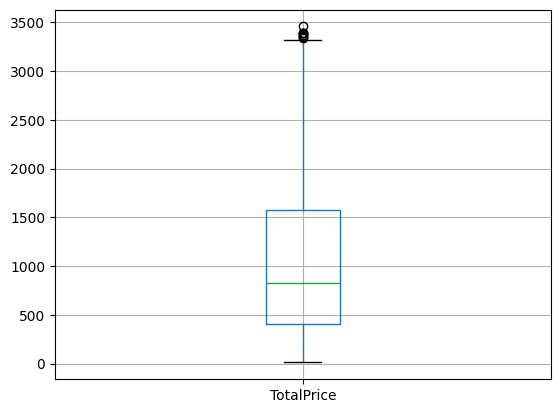

In [20]:
df.boxplot(column="TotalPrice")
plt.show()

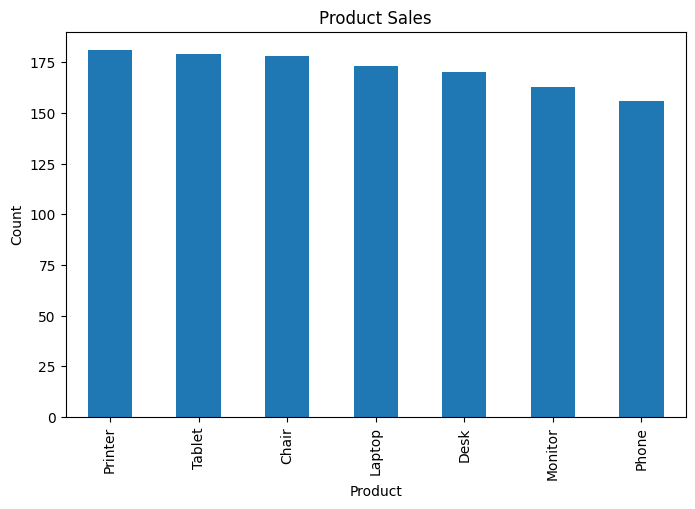

In [21]:
import matplotlib.pyplot as plt

df["Product"].value_counts().plot(kind="bar", figsize=(8,5))
plt.title("Product Sales")
plt.xlabel("Product")
plt.ylabel("Count")
plt.show()

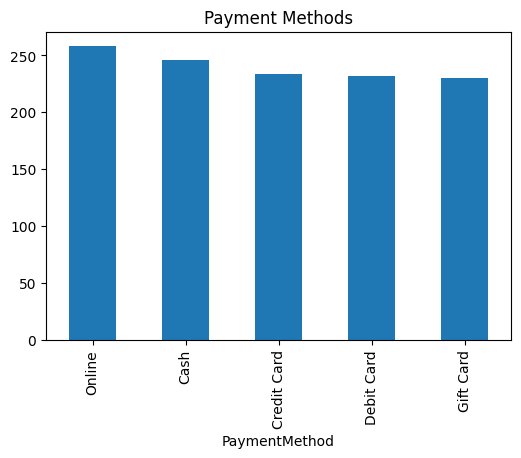

In [22]:
df["PaymentMethod"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Payment Methods")
plt.show()

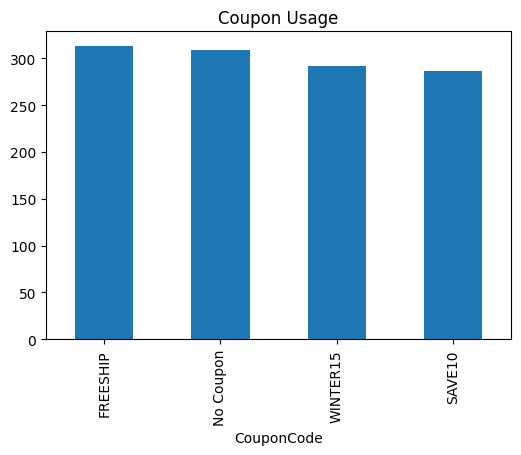

In [23]:
df["CouponCode"].value_counts().plot(kind="bar", figsize=(6,4))
plt.title("Coupon Usage")
plt.show()

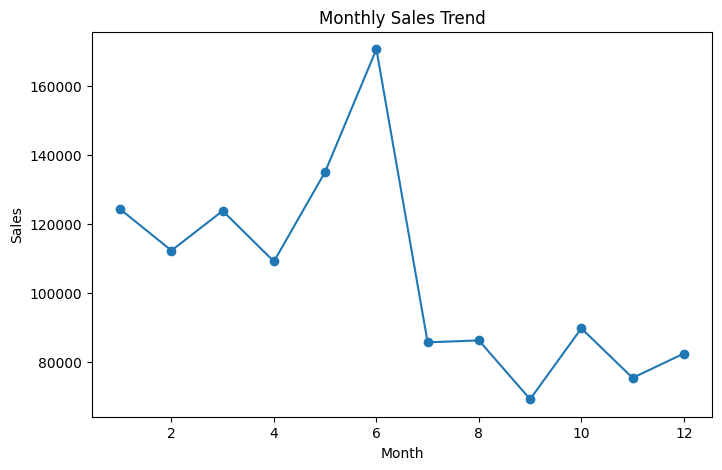

In [24]:
monthly_sales = df.groupby(df["Date"].dt.month)["TotalPrice"].sum()

monthly_sales.plot(kind="line", marker="o", figsize=(8,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

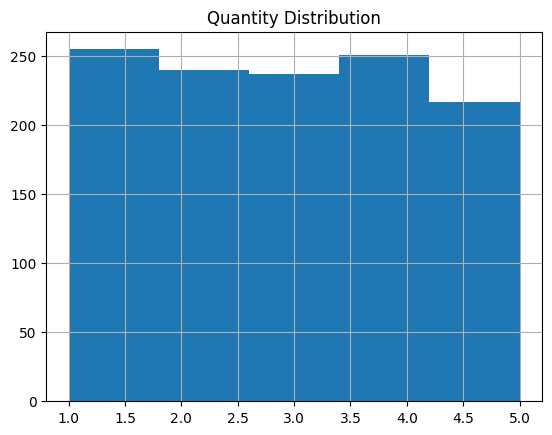

In [25]:
df["Quantity"].hist(bins=5)
plt.title("Quantity Distribution")
plt.show()

Observations:
1. The dataset contains 1200 rows and 14 columns.
2. There were 309 missing values in the CouponCode column, which were replaced with "No Coupon" during    Project 1.
3. No duplicate rows were found in the dataset.
4. The average order value is approximately 1053.97.
5. The average quantity ordered is approximately 2.95 items.
6. The most sold product was identified using the product frequency analysis.
7. Payment methods were analyzed to identify the most commonly used payment option.
8. Coupon usage analysis showed the distribution of different discount codes.
9. Monthly sales trends were analyzed to observe changes in revenue over time.
10. A box plot was used to identify possible outliers in the TotalPrice column.